# Solution Part 2

Commit your final solution for Part 2 within this notebook. Your submission should be as **self-contained** as possible, but you may reference additional notebooks if necessary.

The `data` folder in this repository contains the following:
- `smoothed_vp.py`: Initial 'guess' of vp values on a 401 x 401 grid.
- `shot_0.npy` - `shot_8.npy`: Shot records: The field data (i.e. $\mathbf{d}$) to be used for generating the objective functon.
- `time_values.npy`: The points in time at which the data at each receiver was recorded.

In [37]:
# Some required imports

import numpy as np
import matplotlib.pyplot as plt

from devito import TimeFunction, Operator, Eq, solve, Function
from devito import norm, mmax, mmin
from devito import configuration

from examples.seismic import AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic import Model, plot_velocity
from examples.seismic import plot_shotrecord
from examples.seismic import TimeAxis
from devito import mmax
from examples.seismic import plot_image
configuration['log-level'] = 'WARNING'
%matplotlib inline

In [38]:
print(np.__version__)

2.0.2


In [39]:
'''
WARNING: You should note modify the contents of this cell
'''
# Smoothed/initial model specifications

# NOTE: Using the spacing along with the dimensions of vp_smooth loaded below, the extent of the model
# in each dimension can be computed
spacing = (6.0, 6.0) # Spacing of the model, 6m in each dimension
origin = (0.0, 0.0)  # starting point of the model 

# Load smoothed vp from file:
vp_smooth = np.load('data/smoothed_vp.npy')

# Generate the model: vp will need to be subsampled and a new model created for use in your
# FWI frameworks
model_smooth = Model(vp=vp_smooth, origin=origin, shape=vp_smooth.shape, spacing=spacing,
              space_order=2, nbl=10, bcs="damp")

In [40]:
model_smooth.shape # checking for the original shape value 

(401, 401)

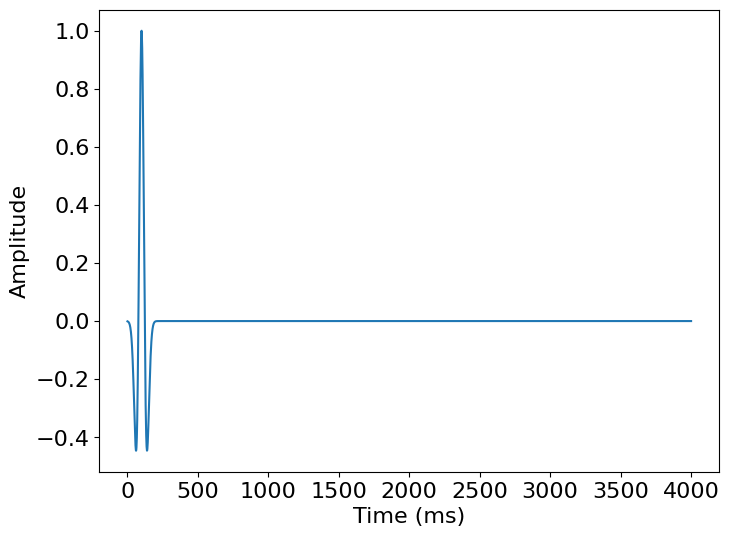

In [41]:
'''
WARNING: You should note modify the contents of this cell
'''
# Aqusition geometry: Details regarding the aquisition gemoetry used to generate the shot records
# in the data folder is provided below:

nshots = 9 # Number of shots
nreceivers = 101  # Number of receiver locations per shot

t0 = 0.
tn = 4000. # 4000ms
f0 = 0.010 # 10Hz (=0.01 kHz)

# Distances below are in meters.

# Position the source for each shot: src_coordinates[0] corresponds to shot_0 and so forth
src_coordinates = np.empty((nshots, 2))
src_coordinates[:, 0] = np.linspace(0., model_smooth.domain_size[0], num=nshots)
src_coordinates[:, 1] = 20

# Receiver locations
rec_coordinates = np.empty((nreceivers, 2))
rec_coordinates[:, 0] = np.linspace(0, model_smooth.domain_size[0], num=nreceivers)
rec_coordinates[:, 1] = 2380

# Create a Geometry:
geometry = AcquisitionGeometry(model_smooth, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')
# We can plot the time signature to see the wavelet
geometry.src.show()

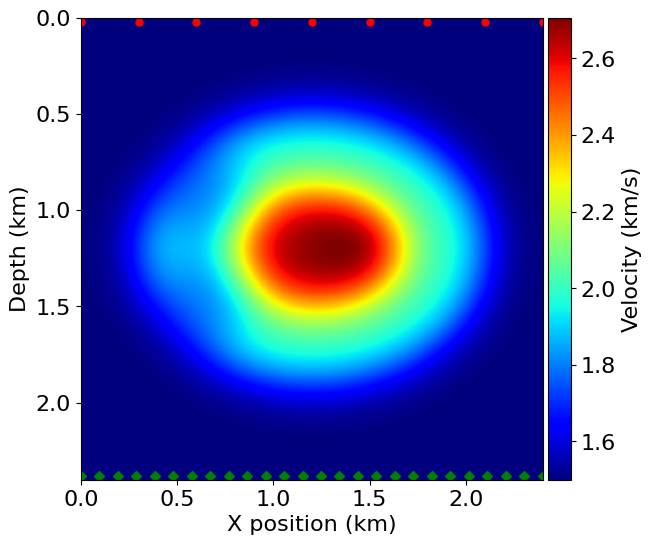

In [42]:
# Plot acquisition geometry over smoothed data
plot_velocity(model_smooth, source=geometry.src_positions,
              receiver=geometry.rec_positions[::4, :])

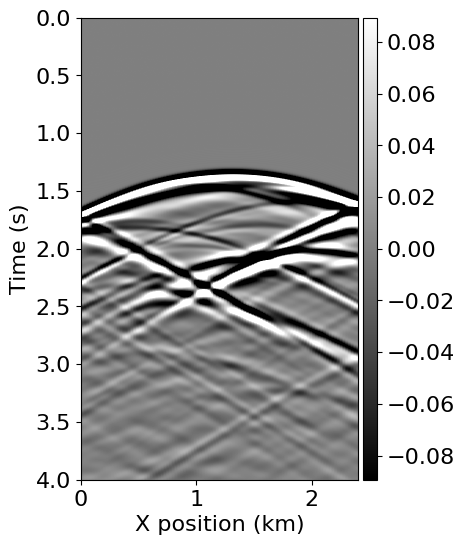

In [43]:
# Shot record example

# Let us load one of the shot records and the associated time values:
shot_record = np.load('data/shot_5.npy')
time_values = np.load('data/time_values.npy')

# Before displaying the shot record we will interpolate
# the data onto a new time axis. This was not necessary, but the code below should
# be useful in several sections of your assessment.

# Initialize interpolated shot record
interpolated_shot_record = np.zeros((len(geometry.time_axis.time_values), shot_record.shape[1]))

# Perform interpolation for each receiver
for receiver in range(shot_record.shape[1]):  
    interpolated_shot_record[:, receiver] = np.interp(geometry.time_axis.time_values, time_values, shot_record[:, receiver])

plot_shotrecord(interpolated_shot_record, model_smooth, t0, tn) # This is our model data

## Solution and analysis

Implement your solution and analysis in cells below here.

## Question 1 — Subsample the smoothed model onto a 101 × 101 grid


### Motivation

The original velocity model `vp_smooth` is defined on a **401 × 401** grid with 6 m spacing. Running FWI at this resolution is computationally prohibitive — it inflates the number of PDE solves, memory usage, and time-per-iteration without proportional benefit during initial experimentation. Subsampling to a **101 × 101** grid reduces the problem to a tractable size while preserving the large-scale velocity structure needed to drive the inversion.


### Procedure

1. Slice `vp_smooth` with stride 4 in each axis (`vp_smooth[::4, ::4]`) to produce a 101 × 101 array — selecting every 4th node.
2. Recompute spacing: the original domain spans $400 \times 6 = 2400$ m per axis; with 100 intervals on the new grid the new spacing is $2400/100 = 24$ m per cell.
3. Confirm the subsampled shape before constructing downstream objects.


In [44]:
 # subsampling the model
vp_new = vp_smooth[::4, ::4]

# initialising the new shape dimension 
shape_new = (101, 101)

# original model dimension : 401 x 401
# Thus, we need to change the spacing value between the grids as weel 
# each axis  is basically : 400 x 6 = 2400 units 
# Thus, the new spacing value will be 2400/100 = 24
spacing_new = (24.0, 24.0)



## Question 2 — Construct a Devito `Model` object for the subsampled grid


### Motivation

Devito's `Model` object is the central container tying the velocity field, grid geometry, absorbing boundary layer (`nbl`), and finite-difference parameters together. All forward solves and gradient computations operate on this object. Constructing it correctly — with consistent `shape`, `spacing`, and `origin` — is a prerequisite for numerically stable wave propagation. The boundary layer `nbl=10` is a conservative baseline; its influence is explored in Experiment 2.


### Procedure

1. Pass `vp_new` (101 × 101) with `origin=(0,0)`, `spacing=(24.0, 24.0)`, `shape=(101, 101)` into `Model`.
2. Set `space_order=2` (assessment default) and `nbl=10` as the initial absorbing boundary width.
3. Use `bcs='damp'` for the damping absorbing boundary condition.
4. Verify with `model_subsampled.shape`.


In [45]:

# creating the new model with the specified dimensions 
model_subsampled = Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=2, nbl=10, bcs="damp")
# checking for the new shape value
model_subsampled.shape 

(101, 101)

## Question 3 — Generate a suitable time axis and interpolate shot records


### Motivation

The provided shot records were sampled at a rate tied to the original 401 × 401 model. The subsampled model has a different `critical_dt` (governed by the CFL condition on the coarser 24 m grid), so the shot data must be **re-interpolated** onto the new time axis before use as observed data $\mathbf{d}_{\text{obs}}$ in the FWI objective. Misaligned time axes would introduce systematic misfit errors unrelated to the velocity model.


Number of traces : 101
Number of traces : 101


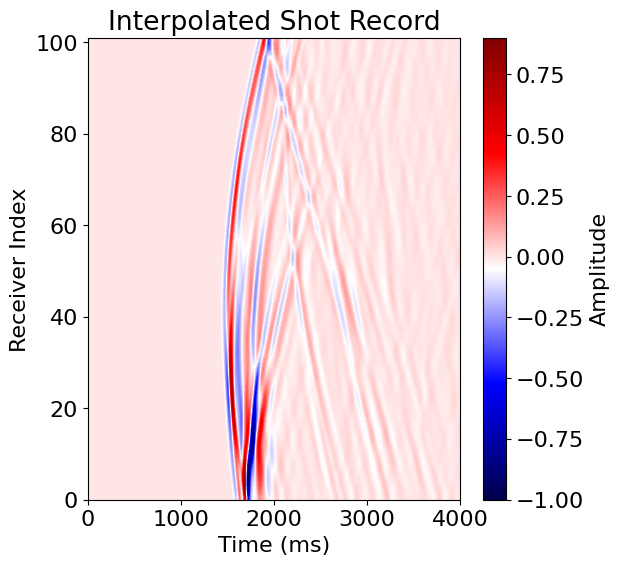

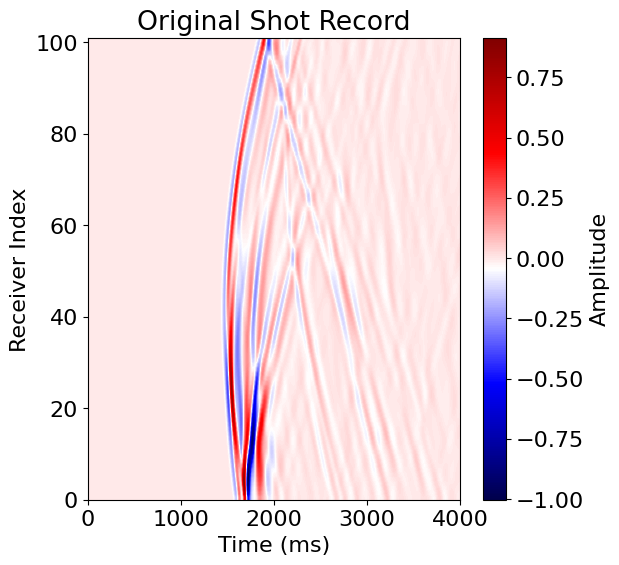

In [46]:
# Reload necessary libraries after execution state reset
import numpy as np
import matplotlib.pyplot as plt

#  Using a random shot record as an example 
shot_record = np.load('data/shot_7.npy')
print("Number of traces :", shot_record.shape[1])
# loading the time values ranging from 0 to 4000 ms
time_values = np.load('data/time_values.npy')


# Define a placeholder time axis (assumed from previous settings)
t0 = 0.0  # Start time in milliseconds
tn = 4000.0  # End time in milliseconds
dt = model_subsampled.critical_dt * 1.25# Assumed time step

# Generate the new time axis
time_axis = np.arange(t0, tn, dt)

# Initialize interpolated shot record
interpolated_shot_record = np.zeros((len(time_axis), shot_record.shape[1]))
print("Number of traces :", interpolated_shot_record.shape[1])
# Perform interpolation for each receiver
for receiver in range(shot_record.shape[1]):  
    interpolated_shot_record[:, receiver] = np.interp(time_axis, time_values, shot_record[:, receiver])

# Plot the interpolated shot record
plt.figure(figsize=(6,6))
plt.imshow(interpolated_shot_record.T, aspect='auto', cmap='seismic', 
           extent=[t0, tn, 0, shot_record.shape[1]])
plt.colorbar(label='Amplitude')
plt.xlabel('Time (ms)')
plt.ylabel('Receiver Index')
plt.title('Interpolated Shot Record')  # Title for the first plot
plt.show()

# Plot the original shot record
plt.figure(figsize=(6,6))
plt.imshow(shot_record.T, aspect='auto', cmap='seismic', 
           extent=[t0, tn, 0, shot_record.shape[1]])
plt.colorbar(label='Amplitude')
plt.xlabel('Time (ms)')
plt.ylabel('Receiver Index')
plt.title('Original Shot Record')  # Title for the second plot
plt.show()


### Visualisation — Original vs Interpolated Shot Records (Shots 1–8)


/tmp/ipykernel_242999/1681494841.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.96])


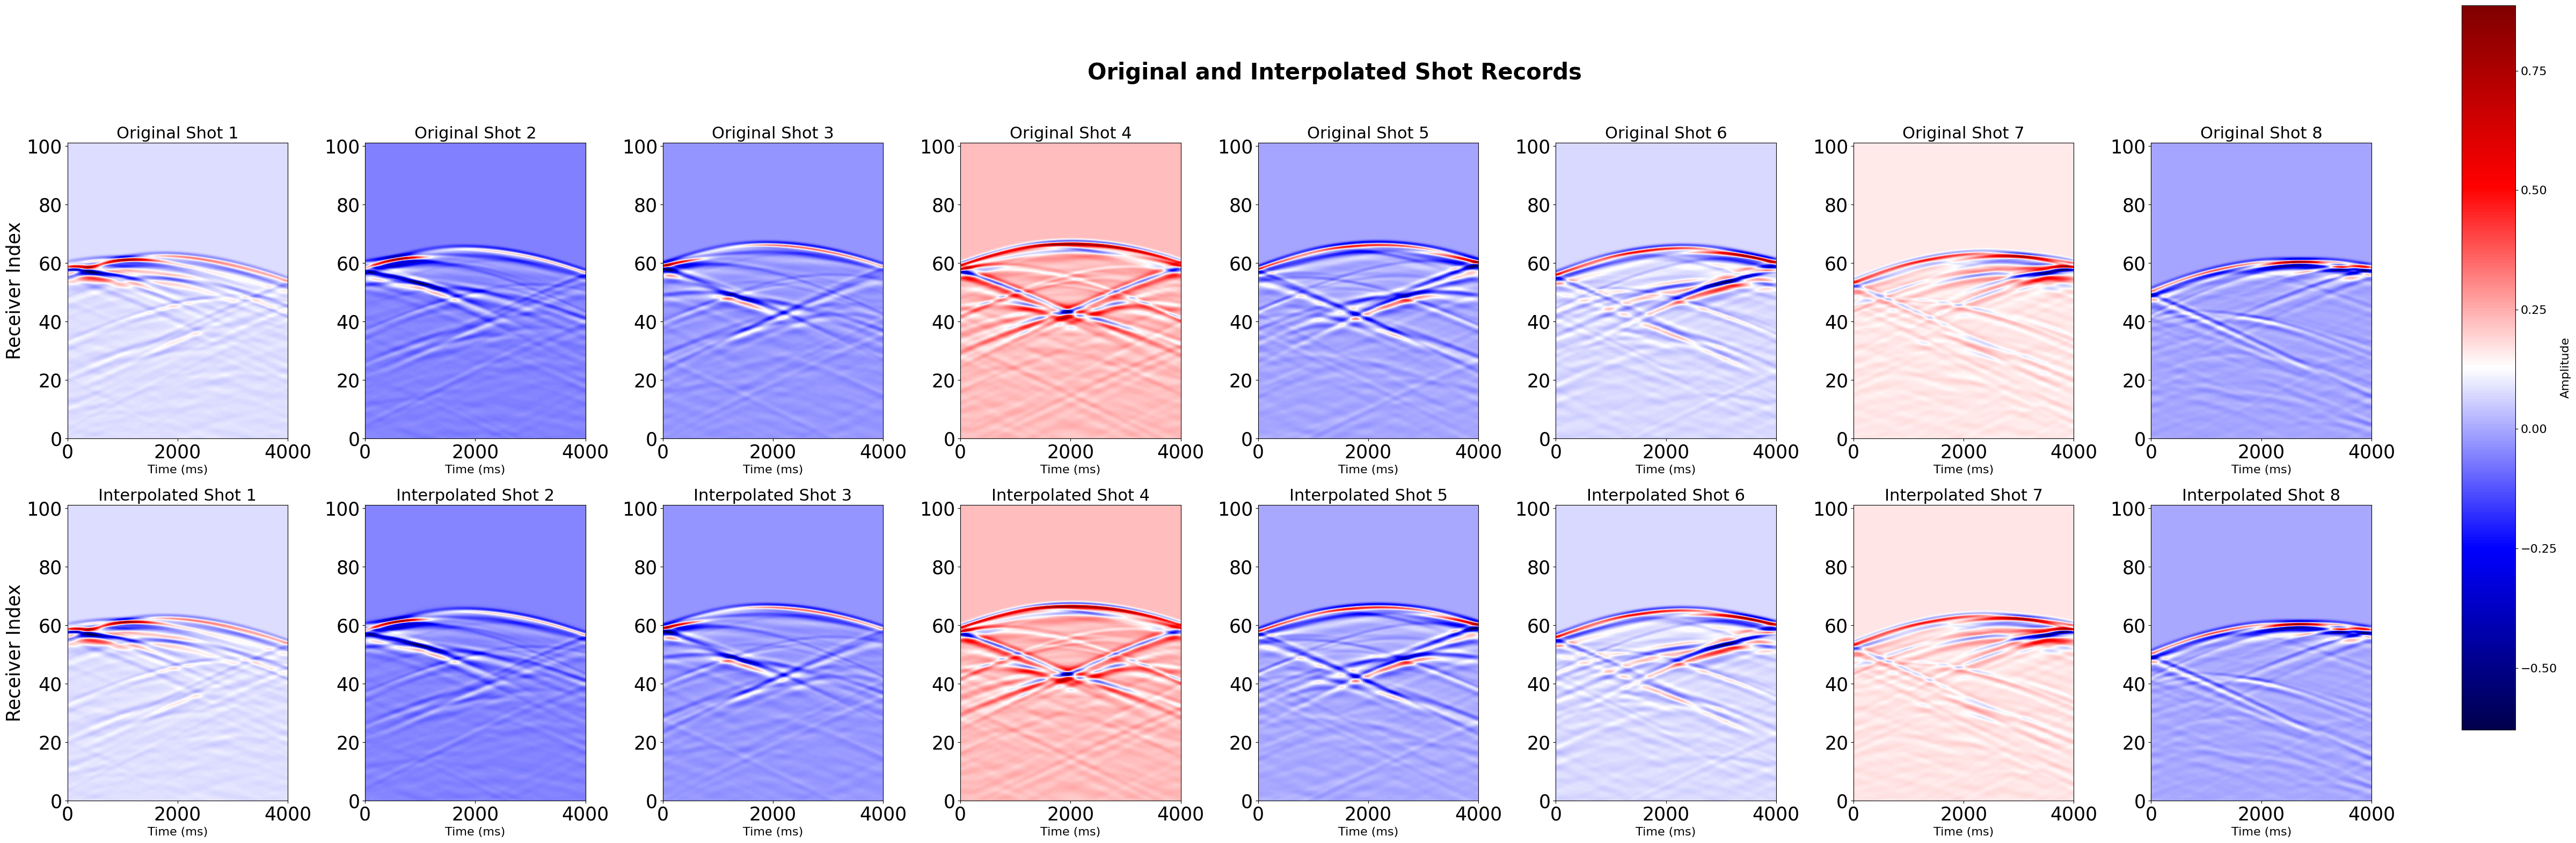

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with subplots (1 row for original, 1 row for interpolated, 8 columns)
fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(50, 15))
fig.suptitle("Original and Interpolated Shot Records", fontsize=30, fontweight='bold')

im2 = None  # Initialize to avoid NameError

# Loop through shot records numbered 1-8
for i in range(1, 9):

    shot_file = np.load(f'data/shot_{i}.npy')


    # Load the shot record
    #shot_record = np.load(shot_file)
    shot_record = shot_file
    # Initialize interpolated shot record
    interpolated_shot_record = np.zeros((len(time_axis), shot_record.shape[1]))

    # Perform interpolation for each receiver
    for receiver in range(shot_record.shape[1]):  
        interpolated_shot_record[:, receiver] = np.interp(time_axis, time_values, shot_record[:, receiver])

    # Plot the original shot record
    ax_original = axes[0, i - 1]
    ax_original.imshow(shot_record, aspect='auto', cmap='seismic', extent=[t0, tn, 0, shot_record.shape[1]])
    ax_original.set_xlabel('Time (ms)')
    ax_original.set_title(f'Original Shot {i}', fontsize=22)
    # **Change the font size of X and Y tick labels**
    ax_original.tick_params(axis='x', labelsize=25)  # Change X-axis tick font size
    ax_original.tick_params(axis='y', labelsize=25)  # Change Y-axis tick font size
    if i == 1:
        ax_original.set_ylabel('Receiver Index', fontsize=25)

    # Plot the interpolated shot record
    ax_interpolated = axes[1, i - 1]
    im2 = ax_interpolated.imshow(interpolated_shot_record, aspect='auto', cmap='seismic', extent=[t0, tn, 0, shot_record.shape[1]])
    ax_interpolated.set_xlabel('Time (ms)')
    ax_interpolated.set_title(f'Interpolated Shot {i}', fontsize=22)
    ax_interpolated.tick_params(axis='x', labelsize=25)  # Change X-axis tick font size
    ax_interpolated.tick_params(axis='y', labelsize=25)  # Change Y-axis tick font size
    if i == 1:
        ax_interpolated.set_ylabel('Receiver Index', fontsize=25)

# Add a single colorbar only if im2 exists
if im2 is not None:
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.9])  # Position for colorbar
    fig.colorbar(im2, cax=cbar_ax, label="Amplitude", ticks = [-1, -0.75, -0.50, -0.25, 0, 0.25, 0.50, 0.75, 1])  # Add colorbar with label and ticks

# Adjust layout and show the plot
plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()


### Procedure

1. Compute `dt = model_subsampled.critical_dt × 1.25` (CFL stability with safety margin), then build `time_axis = np.arange(t0, tn, dt)`.
2. For each receiver trace: `np.interp(time_axis, time_values, trace)` — linear interpolation onto the new grid.
3. Plot all 8 original and interpolated shot records in a 2-row grid for side-by-side comparison.

### Observation

The interpolated records are visually consistent with the originals — dominant wavefronts, hyperbolic moveout patterns, and amplitude envelopes are all preserved. Mild smoothing of high-frequency components is visible as a slight reduction in sharpness of fast oscillations (most apparent in the 200–400 sample window of the difference trace). This is expected from linear interpolation onto a lower-rate grid and does not compromise the low-frequency kinematic content that FWI relies on at early iterations.


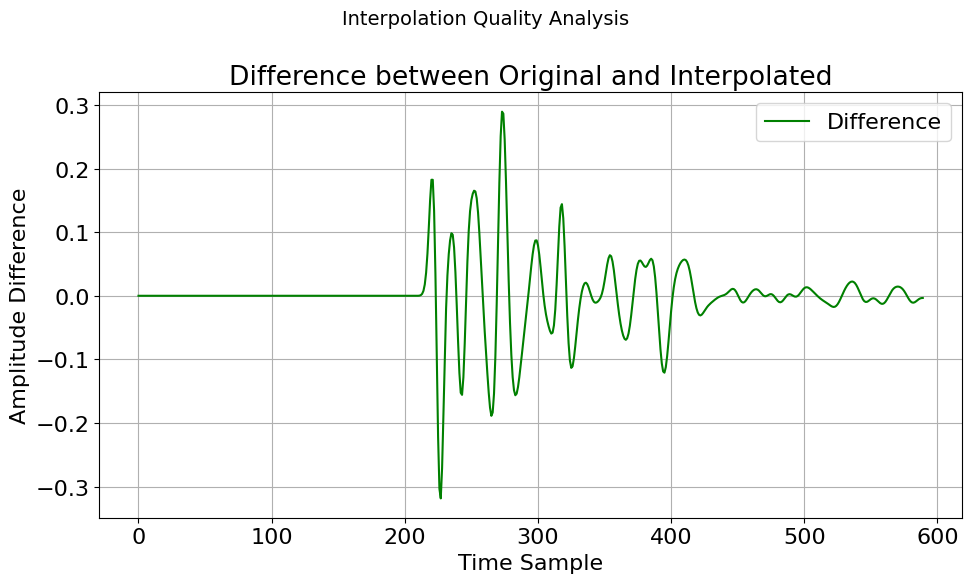

In [48]:

# Load a sample shot record for interpolation analysis (Shot 1)
shot_file = 'data/shot_1.npy'
shot_record = np.load(shot_file)

# Initialize interpolated shot record
interpolated_shot_record = np.zeros((len(time_axis), shot_record.shape[1]))

# Perform interpolation for each receiver
for receiver in range(shot_record.shape[1]):
    interpolated_shot_record[:, receiver] = np.interp(time_axis, time_values, shot_record[:, receiver])

def plot_interpolation_quality(original_data, interpolated_data, trace_number=50):
    """
    Creates a detailed comparison plot showing interpolation quality for seismic data.
    
    Parameters:
    original_data: numpy array of original shot record
    interpolated_data: numpy array of interpolated shot record
    trace_number: which trace to analyze in detail (default 5)
    """
    
    # Create figure with subplots
    fig, (ax2) = plt.subplots(1, 1, figsize=(10, 6))
    fig.suptitle('Interpolation Quality Analysis', fontsize=14)

    # Time axis for plotting traces
    time_axis_original = np.arange(original_data.shape[0])
    time_axis_interp = np.arange(interpolated_data.shape[0])

    # Plot 2: Difference between original and interpolated
    min_length = min(len(original_data[:, trace_number]), len(interpolated_data[:, trace_number]))
    difference = original_data[:min_length, trace_number] - interpolated_data[:min_length, trace_number]
    ax2.plot(time_axis_original[:min_length], difference, 'g-', label='Difference')
    ax2.set_title('Difference between Original and Interpolated')
    ax2.set_xlabel('Time Sample')
    ax2.set_ylabel('Amplitude Difference')
    ax2.legend()
    ax2.grid(True)

    # Adjust layout
    plt.tight_layout()
    return fig

# Example usage:
fig = plot_interpolation_quality(shot_record, interpolated_shot_record, trace_number=50)
plt.show()


#### Observation — Interpolation Difference (Trace 50, Shot 1)

The difference plot reveals three distinct regimes:

- **Samples 0–200 (zero error):** No seismic arrivals; the signal is flat and interpolation trivially reproduces it.
- **Samples 200–400 (peak error):** First seismic arrivals appear here. Linear interpolation cannot fully reconstruct rapid phase transitions, producing visible amplitude deviations and concentrated high-frequency loss.
- **Samples 400+ (residual drift):** Error decays but persists at low amplitude, consistent with ongoing linear approximation of smoothly varying waveforms.

The interpolation factor (~0.16×) confirms significant time-axis downsampling. Low-frequency wavefield structure — which drives gradient accuracy in FWI — is well preserved.


### Impact on Wave Propagation Fidelity

| Grid | Node spacing | Min resolvable feature (`space_order=2`) |
|---|---|---|
| Original (401×401) | 6 m | ~12 m |
| Subsampled (101×101) | 24 m | ~48 m |

For the 10 Hz Ricker wavelet used here (dominant wavelength ~200–300 m at typical crustal velocities), the wavelet is spatially oversampled even on the coarser grid. Fine-scale scattering detail is sacrificed, but the low-frequency kinematic signal that FWI inverts for is faithfully preserved.


In [49]:
# Computing the interpolation factor (x)
original_time_steps = len(time_values)  # Number of time steps in original shot record
interpolated_time_steps = len(time_axis)  # Number of time steps after interpolation

# Interpolation factor (x) = how many times the new time steps fit into the original
interpolation_factor = interpolated_time_steps / original_time_steps

# Display the result
interpolation_factor


0.16439119531903038

---


## Question 4 — Implement FWI Inversion


### Motivation

FWI minimises the $L_2$ misfit between observed and synthetic shot records:

$$\phi(\mathbf{m}) = \frac{1}{2} \|\mathbf{d}_{\text{syn}}(\mathbf{m}) - \mathbf{d}_{\text{obs}}\|^2$$

The gradient $\nabla_\mathbf{m}\phi$ is computed via the adjoint-state method — one additional PDE solve — and used to iteratively update the velocity model toward the true subsurface structure. The smoothed initial model provides a kinematically consistent starting point to avoid cycle-skipping.

### Procedure

**Step 1 — Acquisition geometry**

- 9 sources distributed evenly across the model surface at 20 m depth.
- 101 receivers at 2380 m depth (transmission geometry).
- Ricker wavelet at 10 Hz (`f0=0.010 kHz`) matching the provided shot data.
- `AcquisitionGeometry` built on `model_subsampled` to ensure time-axis consistency.


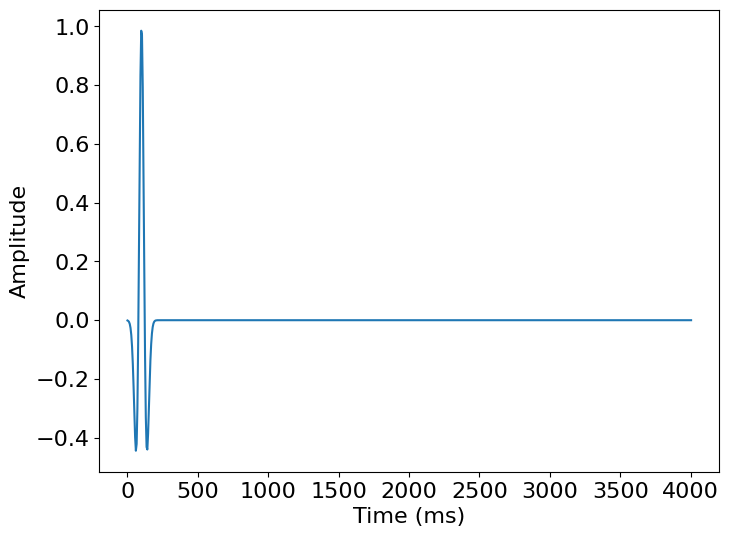

In [50]:

# Let us load one of the shot records and the associated time values:
shot_record = np.load('data/shot_5.npy')
time_values = np.load('data/time_values.npy')


# Define a placeholder time axis (assumed from previous settings)
t0 = 0.0  # Start time in milliseconds
tn = 4000.0  # End time in milliseconds
dt = model_subsampled.critical_dt # Assumed time step

# Generate the new time axis
time_axis = np.arange(t0, tn, dt)

# Position the source for each shot: src_coordinates[0] corresponds to shot_0 and so forth
src_coordinates = np.empty((nshots, 2))
src_coordinates[:, 0] = np.linspace(0., model_subsampled.domain_size[0], num=nshots)
src_coordinates[:, 1] = 20

# Receiver locations
rec_coordinates = np.empty((nreceivers, 2))
rec_coordinates[:, 0] = np.linspace(0, model_subsampled.domain_size[0], num=nreceivers)
rec_coordinates[:, 1] = 2380

# Create the Geometry
# Along with storing the source and receiver locations defined above this will work out the points in time at
# at which we'll need the source signal and compute them according to the definiction of the Ricker-wavelet
geometry_new = AcquisitionGeometry(model_subsampled, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')
# We can plot the time signature to see the wavelet
geometry_new.src.show()

The Ricker wavelet is zero-phase with energy concentrated at the peak frequency (10 Hz). Its rapid temporal decay minimises source-related artefacts in the synthetic records.


In [51]:
nshots,nreceivers

(9, 101)

**Step 2 — Interpolate observed data onto the model time axis**

Each shot record is linearly interpolated onto `geometry_new.time_axis.time_values` to align observed data with the solver's internal time grid before computing residuals.


In [52]:

# Initialize interpolated shot record
interpolated_shot_record = np.zeros((len(geometry_new.time_axis.time_values), shot_record.shape[1]))

# Perform interpolation for each receiver
for receiver in range(shot_record.shape[1]):  
    interpolated_shot_record[:, receiver] = np.interp(geometry_new.time_axis.time_values, time_values, shot_record[:, receiver])

# plot_shotrecord(interpolated_shot_record_new, model_subsampled, t0, tn) # This is our model data
# plot_shotrecord(interpolated_shot_record, model_smooth, t0, tn) # This is our model data

*(Same interpolation as Question 3 — applied per shot inside the inversion loop.)*


**Step 3 — Forward modelling with `AcousticWaveSolver`**

The acoustic wave equation is:

$$\frac{1}{v_p^2} \frac{\partial^2 u}{\partial t^2} - \nabla^2 u = s$$

where $u$ is pressure, $v_p$ is from `model_subsampled.vp`, and $s$ is the Ricker source. Devito discretises with finite differences of order `space_order` in space and 2nd order in time.

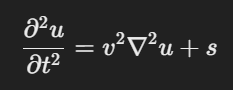

In [53]:
# Compute synthetic data with forward operator 
#Acoustic wave solver : solves the above acoustic wave equation:
from examples.seismic.acoustic import AcousticWaveSolver
 
solver = AcousticWaveSolver(model_subsampled, geometry_new, space_order=4)

`space_order=4` is used for the baseline solver — it provides better accuracy than `space_order=2` with a modest increase in stencil width. The effect of varying `space_order` is explored in Experiment 1.


**Step 4 — Visualise the initial forward-modelled shot record**

Before inversion, the forward model is run on `model_subsampled.vp` to confirm the solver produces physically meaningful shot records and that the geometry is correctly set up.


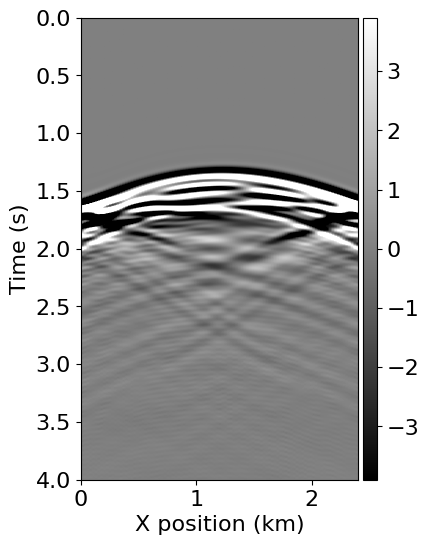

In [54]:
# Compute initial data with forward operator 
smooth_d, _, _ = solver.forward(vp=model_subsampled.vp)
# Plot shot record for true and smooth velocity model and the difference
plot_shotrecord(smooth_d.data, model_subsampled, t0, tn)

#### Observation — Initial forward-modelled shot record

- **X-axis:** Receiver position (m); **Y-axis:** Two-way travel time (ms).

Hyperbolic moveout patterns are clearly visible, consistent with a transmission experiment through a smoothly varying velocity field. The absence of sharp reflectors confirms that the smoothed initial model does not yet contain fine-scale structure — exactly what the FWI iterations will recover.


Bright bands correspond to direct arrivals and first-order refractions. The fading amplitude at larger offsets and later times reflects geometric spreading and damping of waves that have travelled deeper into the model.


**Step 5 — Gradient computation and velocity model update**

The adjoint-state gradient is computed as:

1. **Forward solve:** produce $\mathbf{d}_{\text{syn}}$ and save full wavefield $u_0$.
2. **Residual:** $\delta\mathbf{d} = \mathbf{d}_{\text{obs}} - \mathbf{d}_{\text{syn}}$.
3. **Adjoint solve:** back-propagate $\delta\mathbf{d}$ to produce $\nabla_\mathbf{m}\phi$.
4. **Update:** $\mathbf{m}^{(k+1)} = \mathbf{m}^{(k)} + \alpha \cdot \nabla_\mathbf{m}\phi$, with $\alpha = 0.04 / \max(\nabla_\mathbf{m}\phi)$ and box constraints $v_p \in [1, 4]$ km/s.


In [ ]:
from devito import Eq, Operator, Min, Max  

# Computes the residual between observed and synthetic data into the residual
def compute_residual(residual, dobs, dsyn):
    residual.data[:] = dsyn.data[:] - dobs.data[:]
    
    return residual


Objective value is 191638.421875 at iteration 0
Objective value is 143443.375000 at iteration 1
Objective value is 108204.687500 at iteration 2
Objective value is 83696.164062 at iteration 3
Objective value is 67353.718750 at iteration 4


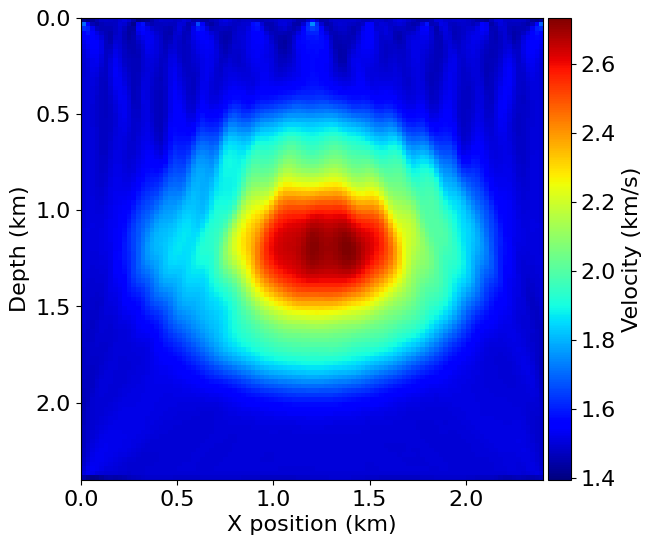

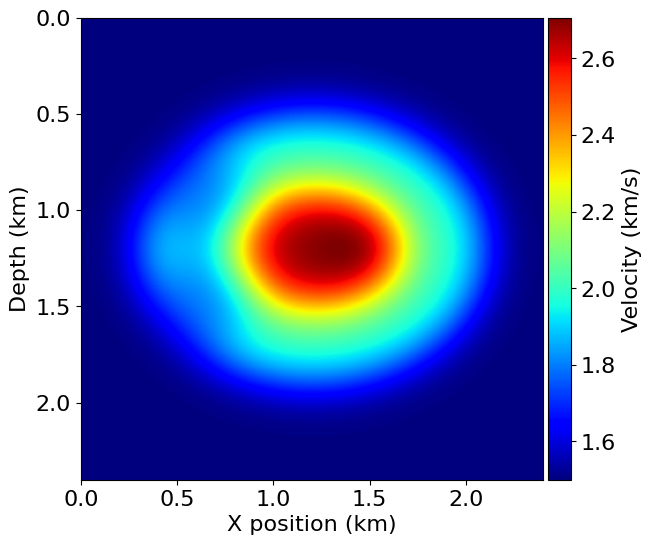

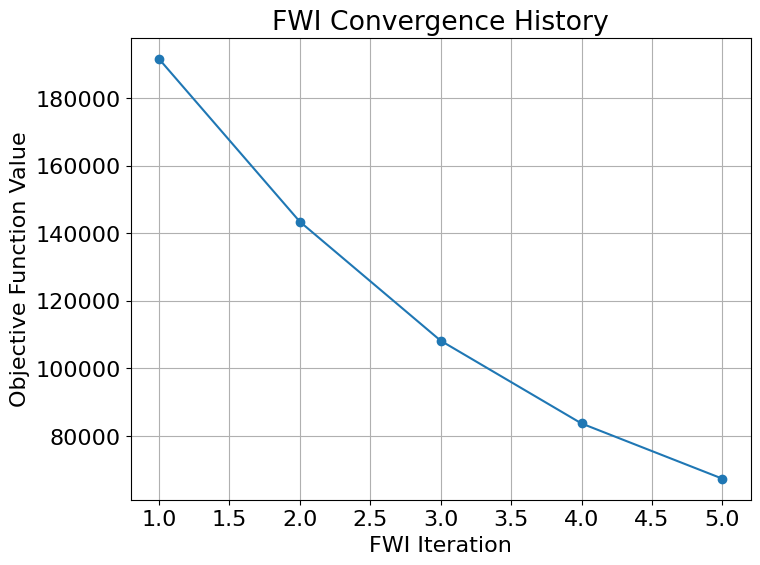

In [ ]:
def fwi_gradient(vp_in, solver, shot_record, time_values):    
    # Create symbols to hold the gradient
    grad = Function(name="grad", grid=solver.model.grid)
    # Create placeholders for the data residual and data
    residual = Receiver(name='residual', grid=solver.model.grid,
                        time_range=solver.geometry.time_axis, 
                        coordinates=solver.geometry.rec_positions)
    d_observation = Receiver(name='d_observation', grid=solver.model.grid,
                        time_range=solver.geometry.time_axis, 
                        coordinates=solver.geometry.rec_positions) # true model
    d_synthetic = Receiver(name='d_synthetic', grid=solver.model.grid,
                        time_range=solver.geometry.time_axis, 
                        coordinates=solver.geometry.rec_positions)# synthetic model
    objective = 0.
    for i, shot_record in enumerate(shot_record):
        solver.geometry.src_positions[0, :] = solver.geometry.src_positions[i, :]
        _, u0, _ = solver.forward(vp=vp_in, save=True, rec=d_synthetic)

        interpolated_shot_record = np.zeros((len(solver.geometry.time_axis.time_values), shot_record.shape[1]))
        for receiver in range(shot_record.shape[1]):
            interpolated_shot_record[:, receiver] = np.interp(solver.geometry.time_axis.time_values, time_values, shot_record[:, receiver])

        d_observation.data[:] = interpolated_shot_record
        residual.data[:] = d_observation.data[:] - d_synthetic.data[:]
        # Compute the residual (difference between synthetic and observed data)

        compute_residual(residual, d_observation, d_synthetic)
        objective += .5*norm(residual)**2
        solver.gradient(rec=residual, u=u0, vp=vp_in, grad=grad)

        return objective, grad

def update_with_box(vp, alpha, dm, vmin=1, vmax=4):
    update = vp + alpha*dm
    update_eq = Eq(vp, Max(Min(update, vmax), vmin))
    Operator(update_eq)()


shot_record = [np.load(f'data/shot_{i}.npy') for i in range(nshots)]

fwi_iterations = 5  # Number of outer FWI iterations
history = np.zeros((fwi_iterations, 1))

for i in range (fwi_iterations):
    # Compute the functional value and gradient for the current
    # model estimate
    phi, direction = fwi_gradient(model_subsampled.vp, solver, shot_record, time_values)
    
    # Store the functional value
    history[i] = phi
    
    alpha = .04 / mmax(direction)
    
    # Update the model estimate and enforce minimum/maximum values
    update_with_box(model_subsampled.vp, alpha, direction)
    # Log the progress made
    print('Objective value is %f at iteration %d' % (phi, i))
    # Plot velocity model update at each iteration
plt.figure(figsize=(7, 6))
plot_velocity(model_subsampled)
plot_velocity(model_smooth)
    # Plot convergence history
#plt.figure(figsize=(8, 6))
plt.plot(range(1, fwi_iterations + 1), history, marker='o', linestyle='-')
plt.xlabel("Iterations")
plt.ylabel("Objective Function Value")
plt.title("FWI Convergence History")
plt.grid()
plt.show()

## Question 5 — Configuration Experiments

Two systematic experiments evaluate how `space_order` and `nbl` independently affect FWI fidelity, convergence, and computational cost. Each experiment varies one parameter while holding all others fixed, enabling clean attribution of observed effects.


In [57]:
# Let us load one of the shot records and the associated time values:
shot_record = np.load('data/shot_5.npy')
time_values = np.load('data/time_values.npy')

# Define a placeholder time axis (assumed from previous settings)
t0 = 0.0  # Start time in milliseconds
tn = 4000.0  # End time in milliseconds

### Experiment 1 — Effect of `space_order`

#### Motivation

`space_order` controls the finite-difference stencil width used to discretise spatial derivatives in the wave equation. Higher-order stencils reduce **numerical dispersion** — the artificial smearing of wavefronts caused by discretisation error — at the cost of a wider computational stencil. For FWI, reducing numerical dispersion improves forward-model fidelity, which directly affects gradient accuracy and the quality of the recovered velocity model. This experiment tests whether the gain in fidelity justifies the added computational cost.

#### Procedure

- Four models constructed with identical parameters except `space_order` ∈ {4, 6, 8, 10}, `nbl=10` fixed.
- Each runs **40 FWI iterations** with step size $\alpha = 0.05 / \max(\nabla_\mathbf{m}\phi)$.
- Three diagnostics per model: forward-modelled shot record, recovered velocity model, and objective function convergence curve $\phi$ vs. iteration.


In [85]:

# creating the new model with the specified dimensions 
model_subsampled_4= Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=4, nbl=10, bcs="damp")
model_subsampled_6= Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=6, nbl=10, bcs="damp")
model_subsampled_8= Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=8, nbl=10, bcs="damp")
model_subsampled_10= Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=10, nbl=10, bcs="damp")
model_list = [model_subsampled_4, model_subsampled_6, model_subsampled_8, model_subsampled_10]

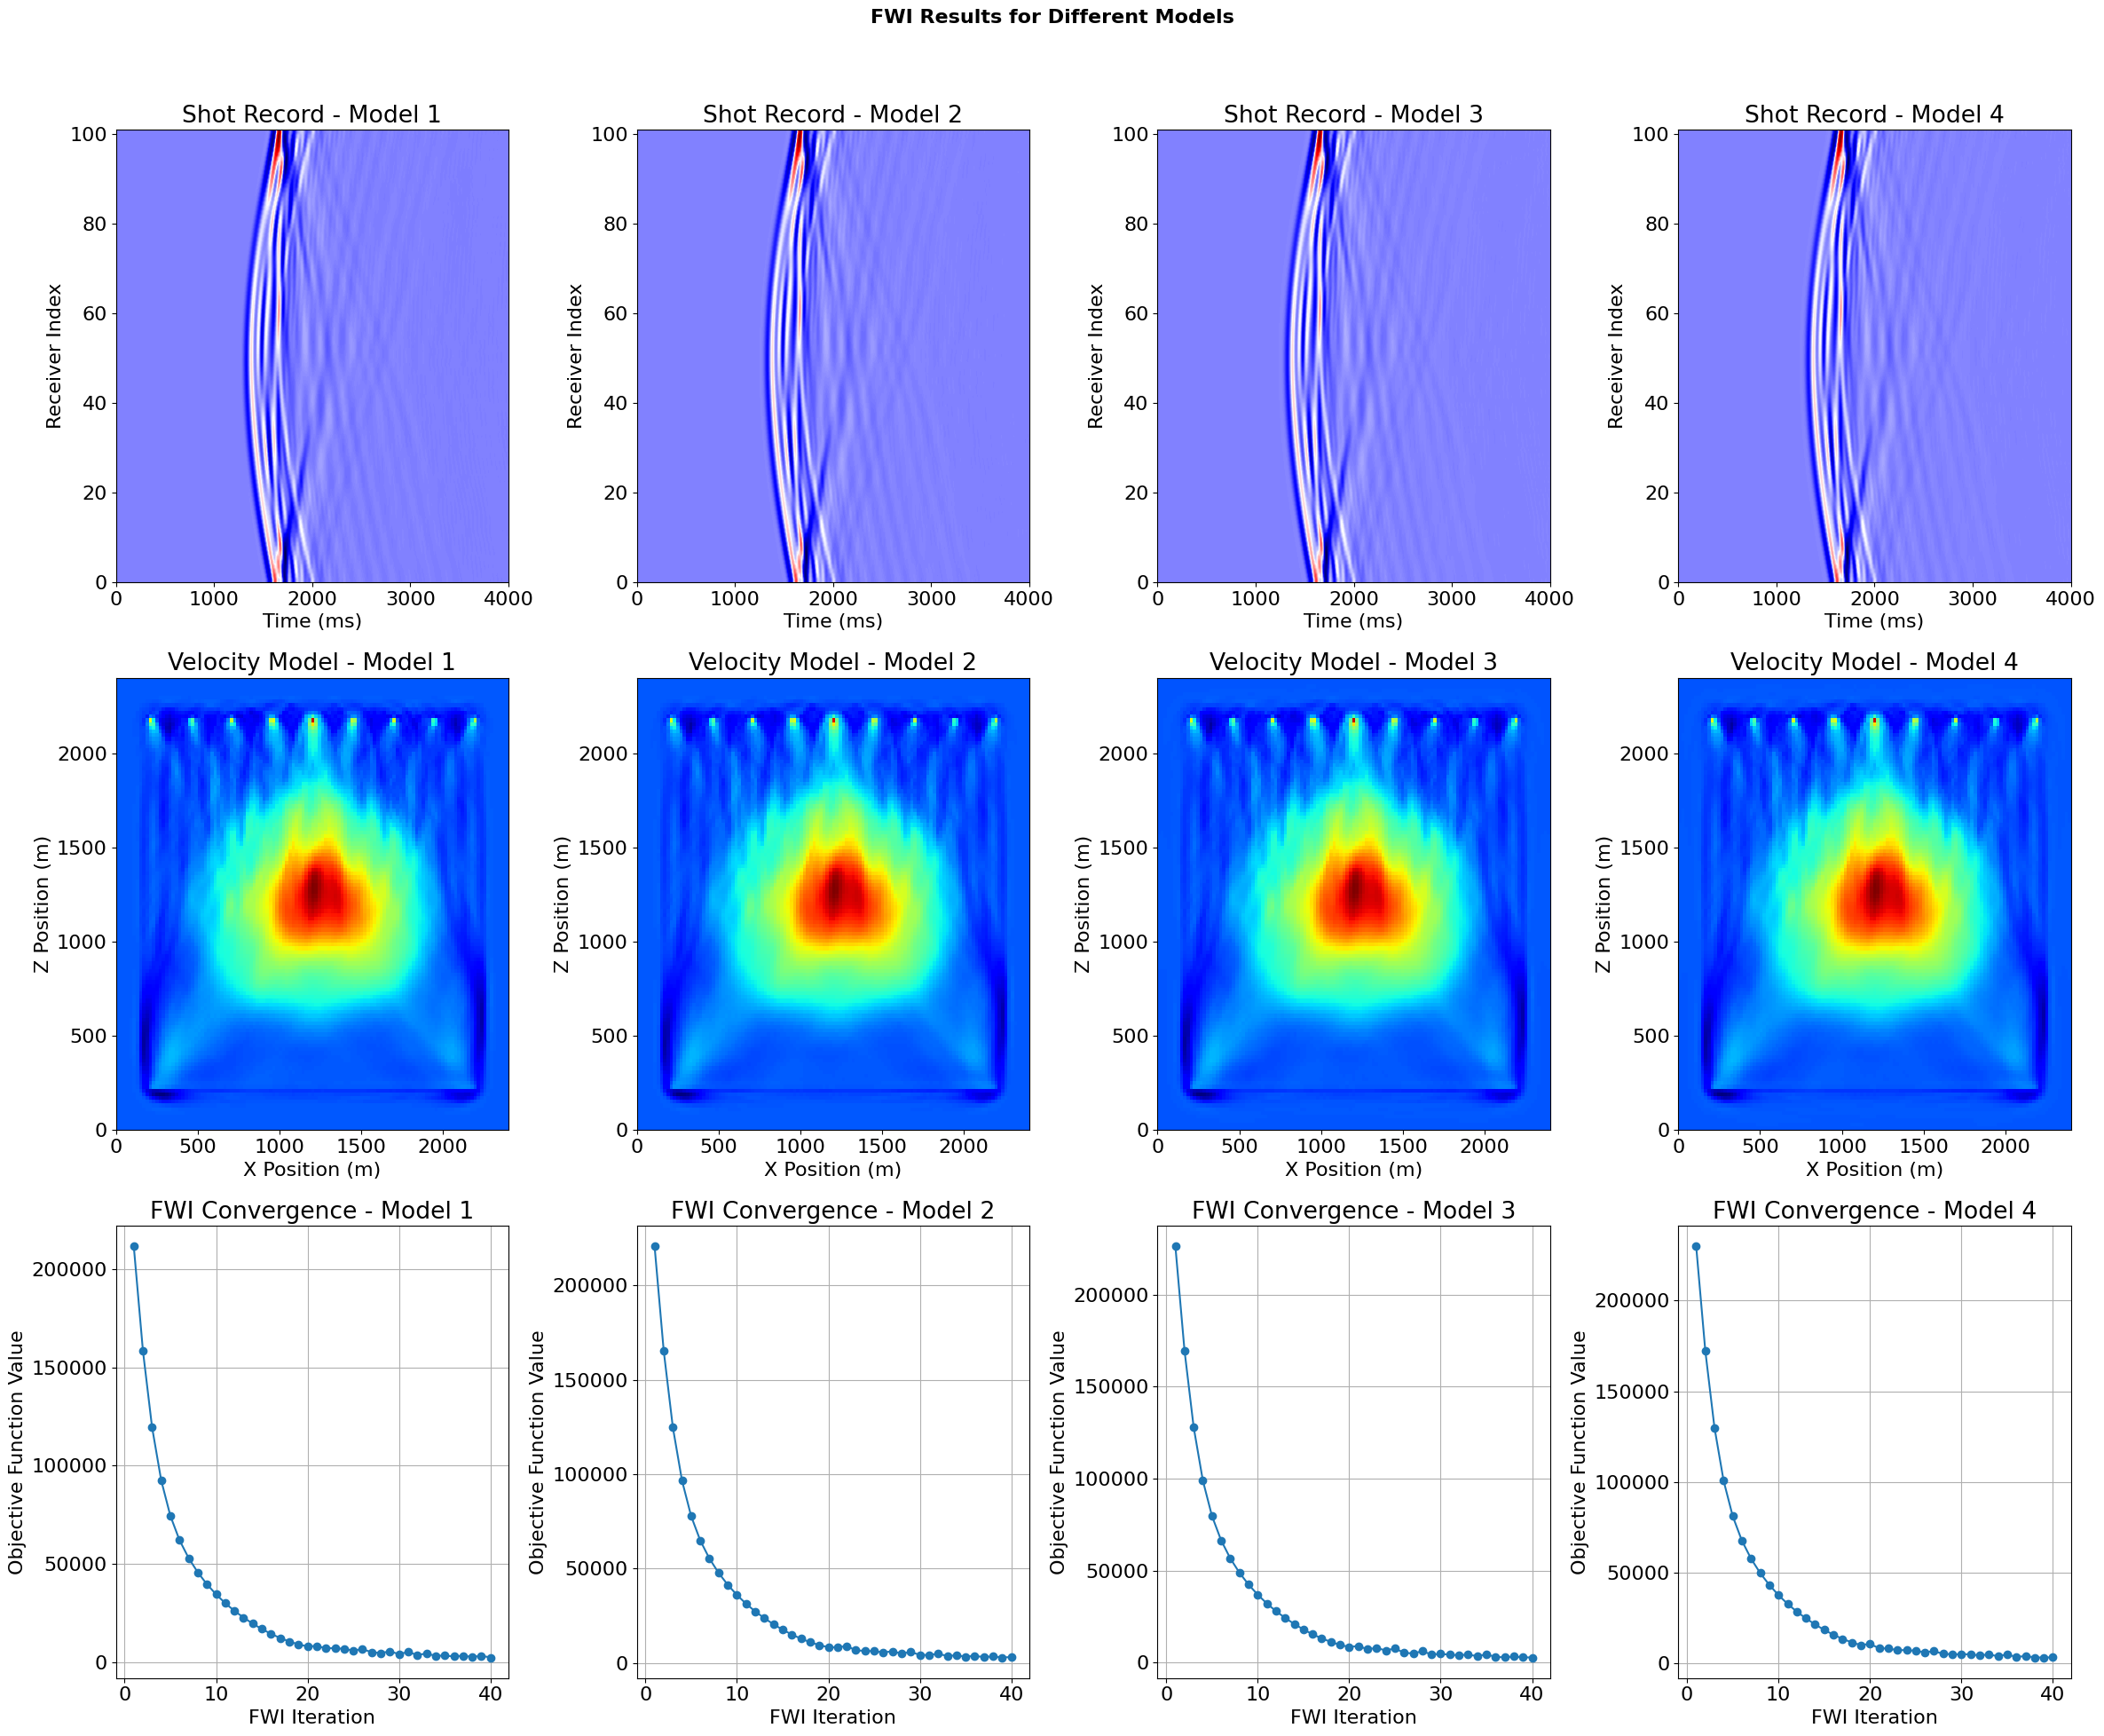

In [86]:
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize=(len(model_list) * 6, 20))
fig.suptitle("FWI Results for Different Models", fontsize=16, fontweight='bold')
shot_record = np.load('data/shot_5.npy')
for index, model_number in enumerate(model_list):
    dt = model_number.critical_dt # Assumed time step

    # Generate the new time axis
    time_axis = np.arange(t0, tn, dt)

    # Position the source for each shot: src_coordinates[0] corresponds to shot_0 and so forth
    src_coordinates = np.empty((nshots, 2))
    src_coordinates[:, 0] = np.linspace(0., model_number.domain_size[0], num=nshots)
    src_coordinates[:, 1] = 20

    # Receiver locations
    rec_coordinates = np.empty((nreceivers, 2))
    rec_coordinates[:, 0] = np.linspace(0, model_number.domain_size[0], num=nreceivers)
    rec_coordinates[:, 1] = 2380

    geometry_new = AcquisitionGeometry(model_number, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')

    interpolated_shot_record = np.zeros((len(geometry_new.time_axis.time_values), shot_record.shape[1]))
    # Perform interpolation for each receiver
    for receiver in range(shot_record.shape[1]):  
        interpolated_shot_record[:, receiver] = np.interp(geometry_new.time_axis.time_values, time_values, shot_record[:, receiver])
    solver = AcousticWaveSolver(model_number, geometry_new, space_order=4)
    # Compute initial data with forward operator 
    smooth_d, _, _ = solver.forward(vp=model_number.vp)
    # Plot shot record for true and smooth velocity model and the difference

    # Plot shot record
    axes[0, index].imshow(smooth_d.data.T, aspect='auto', cmap='seismic', extent=[t0, tn, 0, smooth_d.data.shape[1]])
    axes[0, index].set_title(f"Shot Record - Model {index+1}")
    axes[0, index].set_xlabel("Time (ms)")
    axes[0, index].set_ylabel("Receiver Index")
   # Plot the original shot record
    fwi_iterations = 40  # Number of outer FWI iterations
    history = np.zeros((fwi_iterations, 1))

    for i in range (fwi_iterations):
        # Compute the functional value and gradient for the current
        # model estimate
        phi, direction = fwi_gradient(model_number.vp, solver, shot_records, time_values)
        
        # Store the functional value
        history[i] = phi
        
        # Artificial Step length for gradient descent
        # In practice this would be replaced by a Linesearch (Wolfe, ...)
        alpha = .05 / mmax(direction)
        
        # Update the model estimate and enforce minimum/maximum values
        update_with_box(model_number.vp, alpha, direction)
        # Log the progress made
        
        #print('At iteration %d' % i)
        #print('Phi value is %f at iteration %d' % (phi, i))
    
    
    axes[1, index].imshow(model_number.vp.data.T, aspect='auto', cmap='jet', extent=[0, model_number.domain_size[0], 0, model_number.domain_size[1]])
    axes[1, index].set_title(f"Velocity Model - Model {index+1}")
    axes[1, index].set_xlabel("X Position (m)")
    axes[1, index].set_ylabel("Z Position (m)")
    
    # Plot FWI convergence history
    axes[2, index].plot(range(1, fwi_iterations + 1), history, marker='o', linestyle='-')
    axes[2, index].set_xlabel("FWI Iteration")
    axes[2, index].set_ylabel("Objective Function Value")
    axes[2, index].set_title(f"FWI Convergence - Model {index+1}")
    axes[2, index].grid()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#### Observations

**Shot Records**

Shot records are visually similar across all four models — the large-scale wavefield structure is stable. Minor differences in wavefront sharpness are detectable at higher `space_order`, consistent with reduced numerical dispersion producing marginally crisper arrivals.

**Velocity Models**

Higher `space_order` yields progressively sharper velocity contrasts, particularly in the high-velocity (red) region. The upper low-velocity layer shows little variation, suggesting inversion updates are dominated by the deeper, higher-contrast reflectors regardless of stencil order.

**Convergence**

All models show rapid early descent followed by a plateau around iteration 20–40. Models with `space_order` ∈ {4, 8} achieve similar final $\phi$ values; `space_order` ∈ {6, 10} converge to slightly higher residuals at iteration 40 — likely because the fixed step size is calibrated to the gradient magnitude of the baseline model and does not account for the shifted gradient scale at higher orders.


#### Summary

`space_order=4` delivers the best accuracy-to-cost trade-off for this grid resolution and frequency content. Marginal fidelity gains from higher orders do not offset the growing computational overhead (wider stencil, more operations per PDE solve), and the fixed step size heuristic interacts poorly with the changed gradient magnitudes at higher orders.


### Experiment 2 — Effect of `nbl` (Absorbing Boundary Layer Width)

#### Motivation

`nbl` defines the thickness of the damping layer appended around the domain to absorb outgoing waves and prevent artificial boundary reflections re-entering the domain. Insufficient `nbl` contaminates the residual with spurious reflected energy, degrading gradient quality and introducing artefacts in the recovered model. Excessively large `nbl` inflates the grid and memory footprint without further benefit once reflections are adequately suppressed. This experiment identifies the minimum effective `nbl` for this model and geometry.

#### Procedure

- Five models with `nbl` ∈ {20, 40, 60, 80, 100}, `space_order=4` fixed.
- Each runs **40 FWI iterations** with identical step size and box constraints.
- Diagnostics: shot records (boundary artefacts), velocity models (corner artefacts), convergence curves (stability and final $\phi$).


In [87]:

# creating the new model with the specified dimensions 
model_subsampled_20= Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=4, nbl=20, bcs="damp")
model_subsampled_40= Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=4, nbl=40, bcs="damp")
model_subsampled_60= Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=4, nbl=60, bcs="damp")
model_subsampled_80= Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=4, nbl=80, bcs="damp")
model_subsampled_100= Model(vp=vp_new, origin=origin, shape=shape_new, spacing=spacing_new,
              space_order=4, nbl=100, bcs="damp")
model_list = [model_subsampled_20, model_subsampled_40, model_subsampled_60, model_subsampled_80, model_subsampled_100]

MemoryError: Trying to allocate more memory (225 MB) for `u` than available (128 MB)

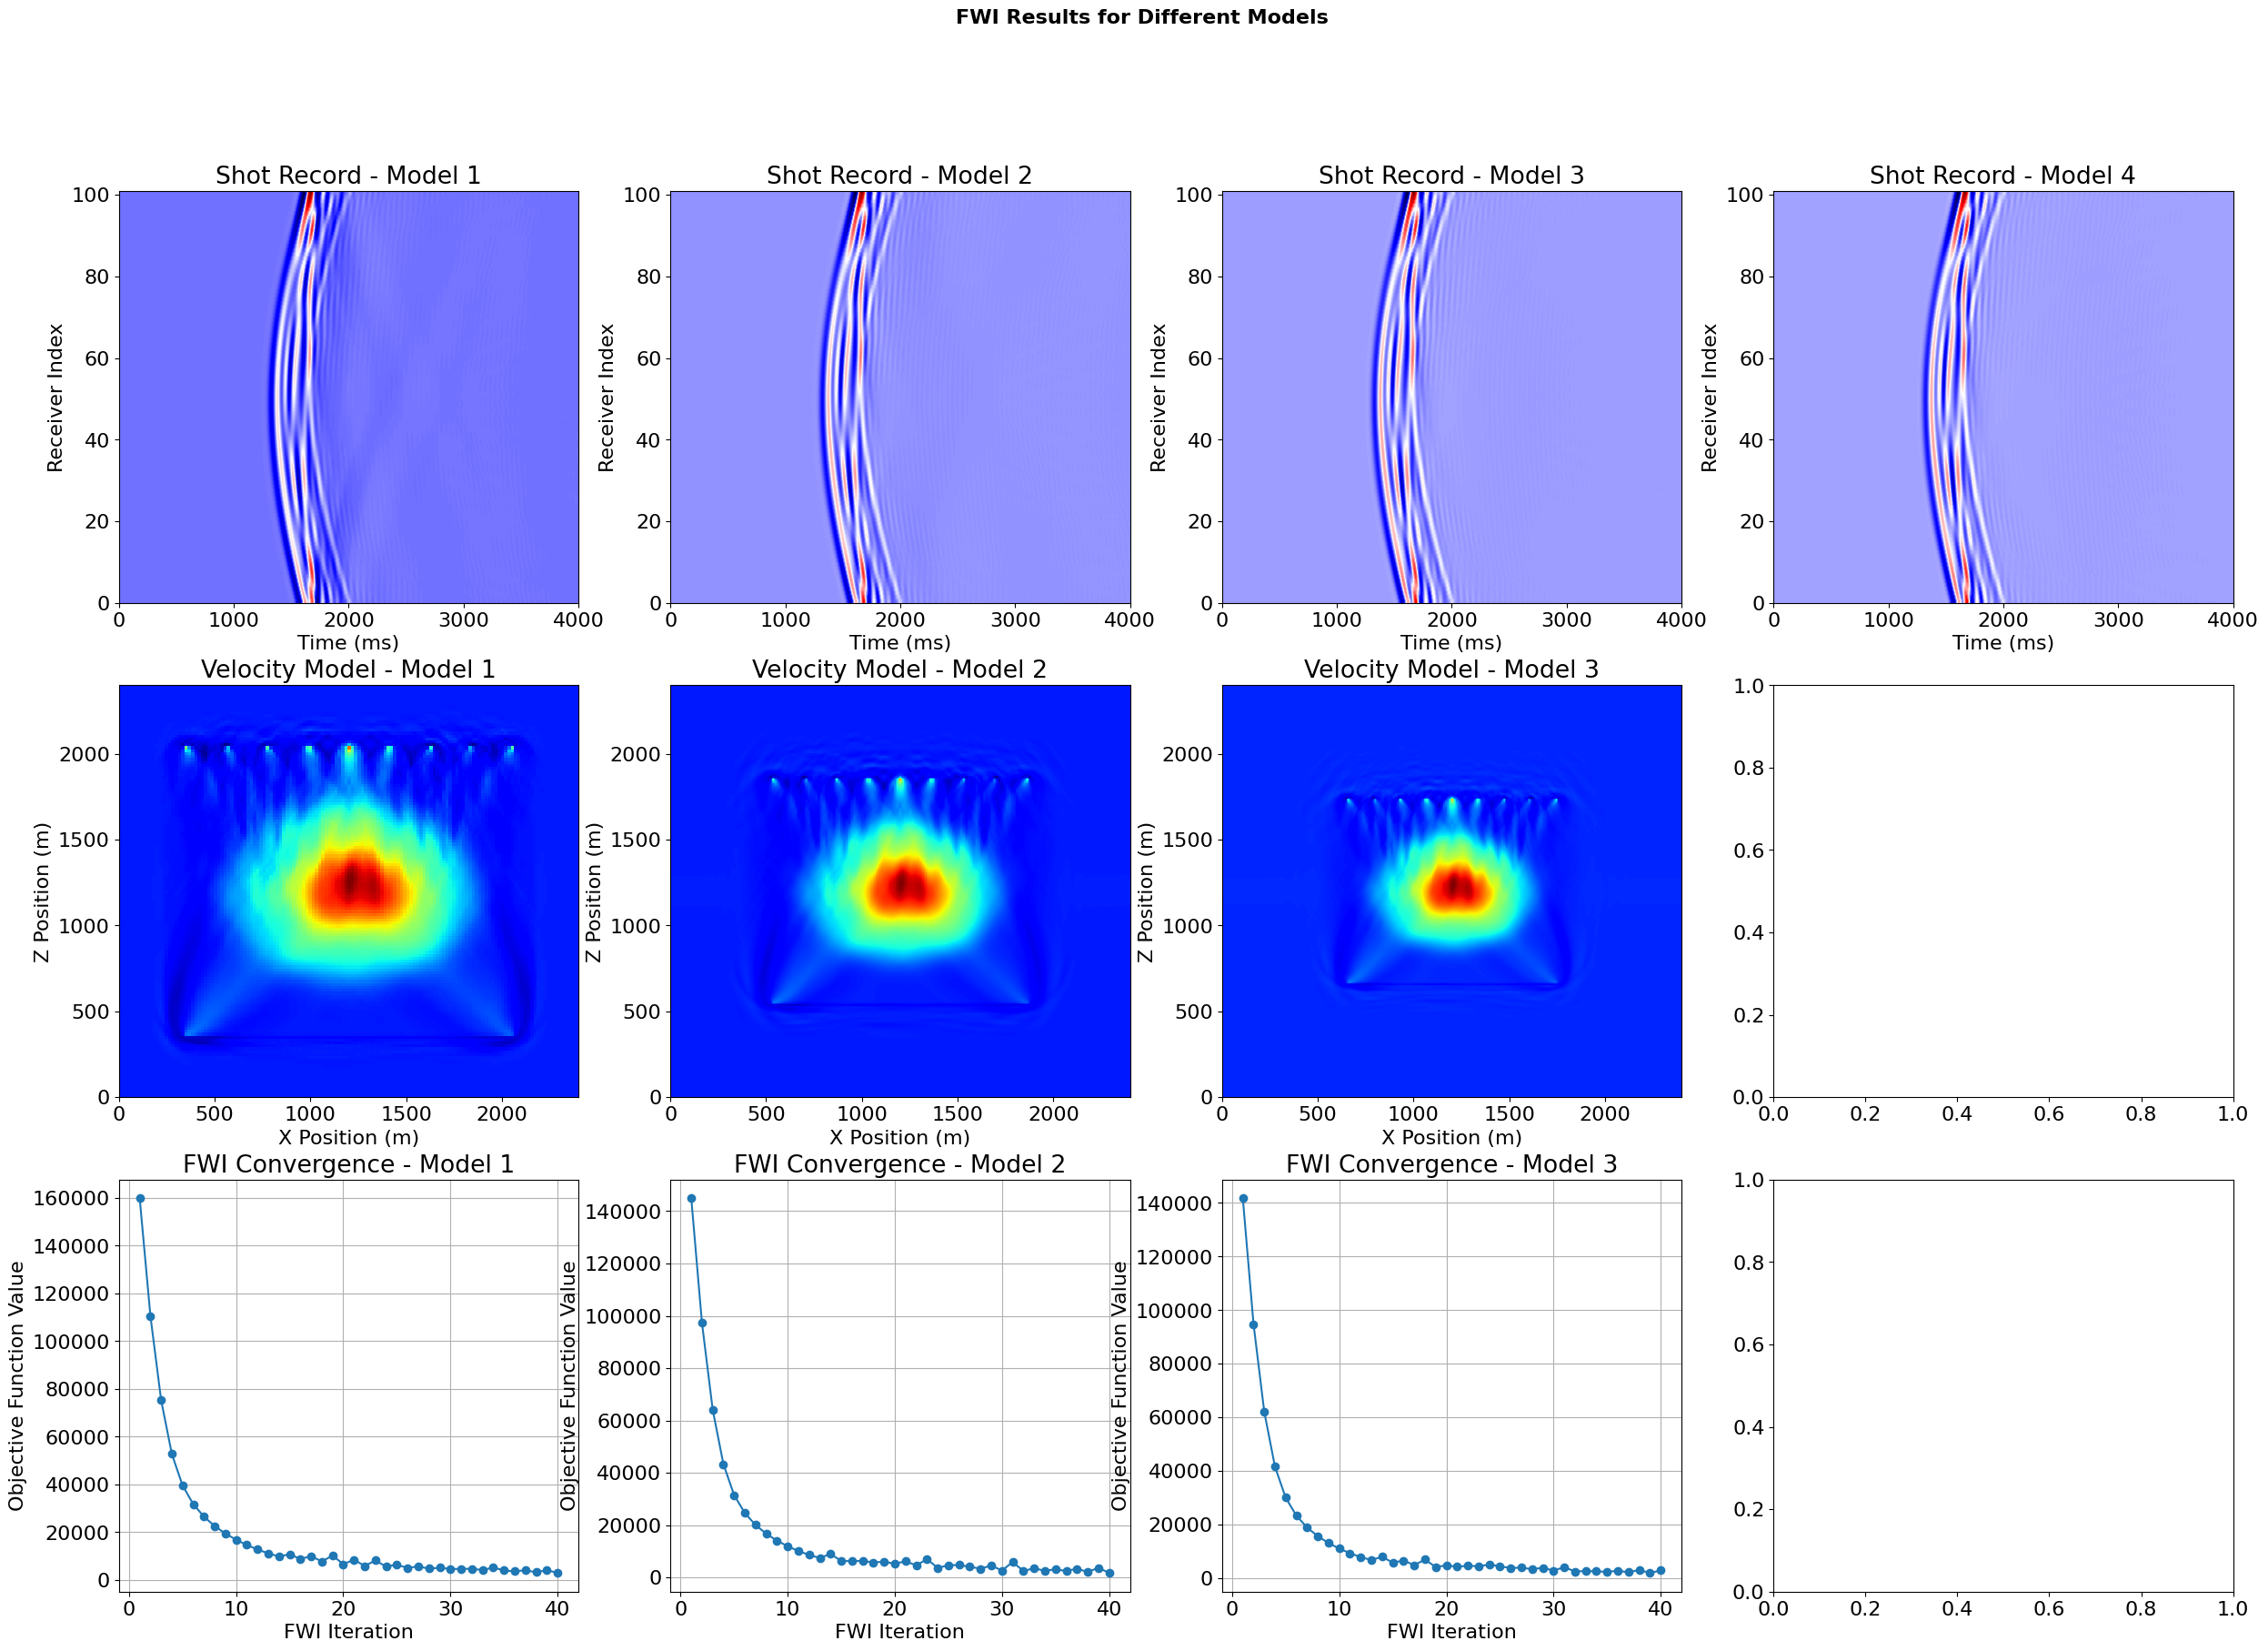

In [88]:
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize=(len(model_list) * 6, 20))
fig.suptitle("FWI Results for Different Models", fontsize=16, fontweight='bold')

for index, model_number in enumerate(model_list):
    dt = model_number.critical_dt # Assumed time step

    # Generate the new time axis
    time_axis = np.arange(t0, tn, dt)

    # Position the source for each shot: src_coordinates[0] corresponds to shot_0 and so forth
    src_coordinates = np.empty((nshots, 2))
    src_coordinates[:, 0] = np.linspace(0., model_number.domain_size[0], num=nshots)
    src_coordinates[:, 1] = 20

    # Receiver locations
    rec_coordinates = np.empty((nreceivers, 2))
    rec_coordinates[:, 0] = np.linspace(0, model_number.domain_size[0], num=nreceivers)
    rec_coordinates[:, 1] = 2380

    geometry_new = AcquisitionGeometry(model_number, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')

    interpolated_shot_record = np.zeros((len(geometry_new.time_axis.time_values), shot_record.shape[1]))
    # Perform interpolation for each receiver
    for receiver in range(shot_record.shape[1]):  
        interpolated_shot_record[:, receiver] = np.interp(geometry_new.time_axis.time_values, time_values, shot_record[:, receiver])
    solver = AcousticWaveSolver(model_number, geometry_new, space_order=4)
    # Compute initial data with forward operator 
    smooth_d, _, _ = solver.forward(vp=model_number.vp)
    # Plot shot record for true and smooth velocity model and the difference

    # Plot shot record
    axes[0, index].imshow(smooth_d.data.T, aspect='auto', cmap='seismic', extent=[t0, tn, 0, smooth_d.data.shape[1]])
    axes[0, index].set_title(f"Shot Record - Model {index+1}")
    axes[0, index].set_xlabel("Time (ms)")
    axes[0, index].set_ylabel("Receiver Index")
   # Plot the original shot record
    fwi_iterations = 40 # Number of outer FWI iterations
    history = np.zeros((fwi_iterations, 1))

    for i in range (fwi_iterations):
        # Compute the functional value and gradient for the current
        # model estimate
        phi, direction = fwi_gradient(model_number.vp, solver, shot_records, time_values)
        
        # Store the functional value
        history[i] = phi
        
        # Artificial Step length for gradient descent
        # In practice this would be replaced by a Linesearch (Wolfe, ...)
        alpha = .05 / mmax(direction)
        
        # Update the model estimate and enforce minimum/maximum values
        update_with_box(model_number.vp, alpha, direction)
        # Log the progress made
        
        #print('At iteration %d' % i)
        #print('Phi value is %f at iteration %d' % (phi, i))
    
    
    axes[1, index].imshow(model_number.vp.data.T, aspect='auto', cmap='jet', extent=[0, model_number.domain_size[0], 0, model_number.domain_size[1]])
    axes[1, index].set_title(f"Velocity Model - Model {index+1}")
    axes[1, index].set_xlabel("X Position (m)")
    axes[1, index].set_ylabel("Z Position (m)")
    
    # Plot FWI convergence history
    axes[2, index].plot(range(1, fwi_iterations + 1), history, marker='o', linestyle='-')
    axes[2, index].set_xlabel("FWI Iteration")
    axes[2, index].set_ylabel("Objective Function Value")
    axes[2, index].set_title(f"FWI Convergence - Model {index+1}")
    axes[2, index].grid()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#### Observations

**Shot Records**

At `nbl=20`, darker amplitude artefacts are visible near model edges — boundary reflections leaking back into the domain. These reduce progressively with increasing `nbl`; models at `nbl=80` and above show clean shot records free of edge contamination.

**Velocity Models**

`nbl` ∈ {20, 40} produce pronounced corner artefacts — high-amplitude velocity anomalies driven by spurious gradient contributions from unabsorbed boundary reflections. Models with `nbl` ≥ 60 recover substantially cleaner, more physically realistic velocity structures.

**Convergence**

Low `nbl` produces noisy convergence curves with visible iteration-to-iteration fluctuation, caused by boundary-reflected energy entering the residual inconsistently. `nbl=80` exhibits the smoothest convergence, approaching near-zero residual by iteration 30. The `nbl=100` case could not be completed at full iterations due to a `MemoryError` from the expanded grid.


### Overall Conclusions

| Parameter | Primary effect | Recommended value |
|---|---|---|
| `space_order` | Controls numerical dispersion and velocity model sharpness; diminishing returns beyond 4 | **4** |
| `nbl` | Controls boundary contamination; insufficient values corrupt gradients and introduce artefacts | **≥ 60** |

The two parameters address orthogonal failure modes: `space_order` governs *numerical accuracy within the domain*, while `nbl` governs *boundary contamination*. Improving one does not compensate for a deficit in the other. For this dataset, `space_order=4` with `nbl=60` provides the best accuracy-to-cost ratio.


### Limitations and Further Work

- **Residual maps:** Per-iteration spatial residual plots would reveal which regions converge slowly and guide targeted shot re-weighting.
- **Line search:** A Wolfe-condition line search would replace the fixed $\alpha$ heuristic, improving convergence stability and decoupling step size from gradient magnitude changes.
- **Extended iterations:** Convergence curves are still descending at iteration 40; running to 80–100 iterations would clarify true convergence and whether higher `space_order` models eventually outperform lower-order ones given more budget.
- **Code packaging:** The experiment loop is nearly identical across Experiments 1 and 2. Refactoring into a single parameterised function would improve reproducibility and reduce setup inconsistency risk.
